### **Preparação para o Tratamento e a Análise de Dados**

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('dados_recrutamento_100.csv')

### **Visualização Inicial dos Dados, Verificação de Dados Errados ou Faltantes e Descrição Geral**

In [6]:
# Visualiação Inicial dos Dados

print("--- Primeiras 5 linhas ---")
print(df.head())



--- Primeiras 5 linhas ---
   ID Departamento            Fonte  Entrevista_Nota      Status  Tempo_Dias
0   1       Vendas  Site da Empresa              9.6  Contratado          11
1   2           TI        Indicação              7.0   Reprovado          32
2   3   Financeiro         LinkedIn              5.5  Contratado          40
3   4           TI        Job Board              6.8   Reprovado          35
4   5           TI        Indicação              5.9   Reprovado           9


In [15]:
# Verificação se há dados faltando no df

print("\n--- Informações do Dataset ---")
print(df.info())


--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               100 non-null    int64  
 1   Departamento     100 non-null    object 
 2   Fonte            100 non-null    object 
 3   Entrevista_Nota  100 non-null    float64
 4   Status           100 non-null    object 
 5   Tempo_Dias       100 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 4.8+ KB
None


In [16]:
# Descrição Geral dos Dados

print(df.describe())

               ID  Entrevista_Nota  Tempo_Dias
count  100.000000       100.000000    100.0000
mean    50.500000         7.451000     24.5700
std     29.011492         1.438609     12.5965
min      1.000000         5.000000      3.0000
25%     25.750000         6.000000     12.0000
50%     50.500000         7.350000     25.0000
75%     75.250000         8.725000     36.0000
max    100.000000         9.900000     45.0000


### **Análise: Aqui realizamos a comparação da diferença das Notas da Entrevista de cada Departamento para identificar se em algum deles há uma discrepância perante à média geral**

In [10]:
# Análise das Médias dos Dados das Notas de Cada Departamento

analise_dept = df.groupby('Departamento')['Entrevista_Nota'].mean().sort_values(ascending=False)

print("\n--- Média de Notas por Departamento ---")
print(analise_dept)


--- Média de Notas por Departamento ---
Departamento
Financeiro    7.839130
RH            7.765000
Vendas        7.431250
Marketing     7.166667
TI            7.026087
Name: Entrevista_Nota, dtype: float64


In [11]:
import matplotlib.pyplot as plt

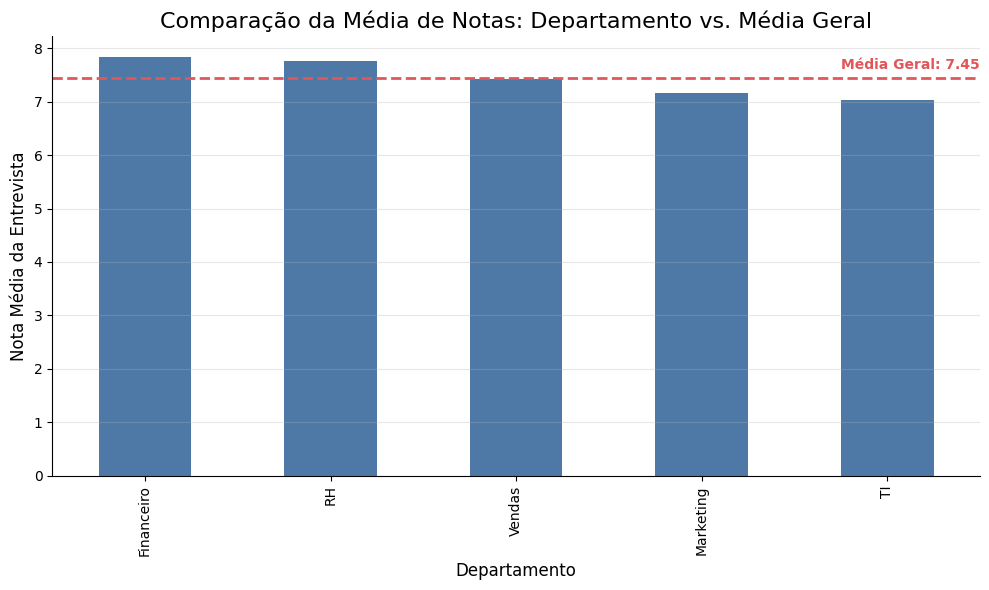

In [14]:
# Criação de Gráfico de Comparação das Médias das Notas das Entrevistas dos Departamentos com a Média Geral

# É possível notar no gráfico que apenas os Departamentos do Financeiro e do RH estão acima da Média Geral. Com isso a empresa pode direcionar ações pontuais nos Departamentos que ficaram abaixo no intuito de colaborar com uma melhor assertividade na avaliação dos candidatos.

fig, ax = plt.subplots(figsize=(10, 6))

analise_dept.plot(kind='bar', color='#4e79a7', ax=ax)

ax.axhline(media_geral, color='#e15759', linestyle='--', linewidth=2)

ax.text(len(analise_dept)-0.5, media_geral + 0.1, f'Média Geral: {media_geral:.2f}', color='#e15759', va='bottom', ha='right', fontweight='bold')

ax.set_title('Comparação da Média de Notas: Departamento vs. Média Geral', fontsize=16)
ax.set_xlabel('Departamento', fontsize=12)
ax.set_ylabel('Nota Média da Entrevista', fontsize=12)
ax.grid(axis='y', linestyle='-', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show() #

### **Neste trecho o intuito é identificar os principais canais de fonte de contratação para melhor gerenciar os recusos**

In [20]:
# Principais Fontes de Contratação

# Analisando é possível perceber que as 3 principais fontes são LinkedIn, Site da Empresa e Indicação. Com esta análise a empresa pode tomar decisões relacionadas a recursos financeiros para esses principais canais.


contratados_apenas = df[df['Status'] == 'Contratado']
fontes_de_contratacao = contratados_apenas['Fonte'].value_counts()
print("--- Fontes com mais Contratações ---")
print(fontes_de_contratacao)

--- Fontes com mais Contratações ---
Fonte
LinkedIn           20
Site da Empresa    17
Indicação          10
Job Board           9
Name: count, dtype: int64


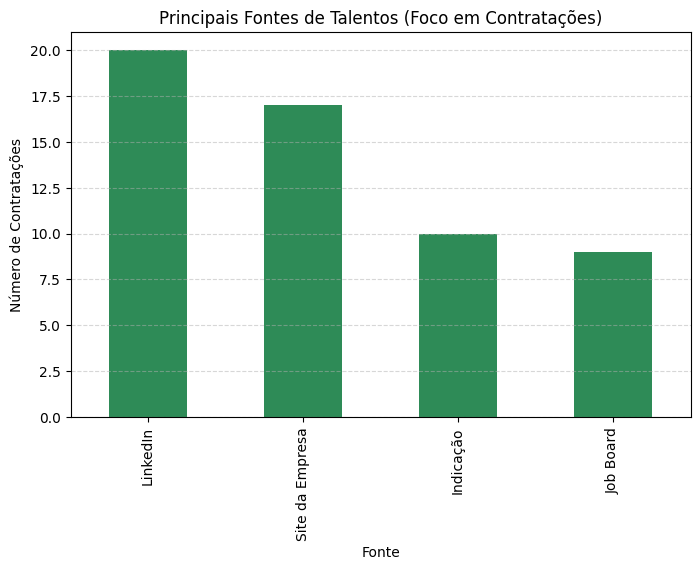

In [23]:
# Gráfico das Principais Fontes de Contratação

plt.figure(figsize=(8, 5))
fontes_de_contratacao.plot(kind='bar', color='seagreen')

plt.title('Principais Fontes de Talentos (Foco em Contratações)')
plt.xlabel('Fonte')
plt.ylabel('Número de Contratações')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### **Com a análise entre a quantidade de contratados e reprovados é possível verificar em quais departamentos está havendo uma maior dificuldade ao ter mais reprovados do aprovados em seus processos**

In [36]:
# Análise de Quantidade de Contratados x Reprovados

# Nesse tópico é possível analisar alguns departamentos possuem mais contratados do que reprovados (Financeiro, RH e Vendas) enquanto que os outros possuem o contrário. Com isso, a empresa pode optar por outras formas de avaliação.

analise_status = pd.crosstab(df['Departamento'], df['Status'])

print("\n--- Volume de Hires/Rejections por Área ---")
print(analise_status)




--- Volume de Hires/Rejections por Área ---
Status        Contratado  Reprovado
Departamento                       
Financeiro            12         11
Marketing              8         10
RH                    15          5
TI                    10         13
Vendas                11          5


### **Neste tópico é possível perceber quais são os Departamentos que mais estão tendo contratações para direcionar ações aos que estão com um menor número e aprender com os que estão tendo bons resultados**

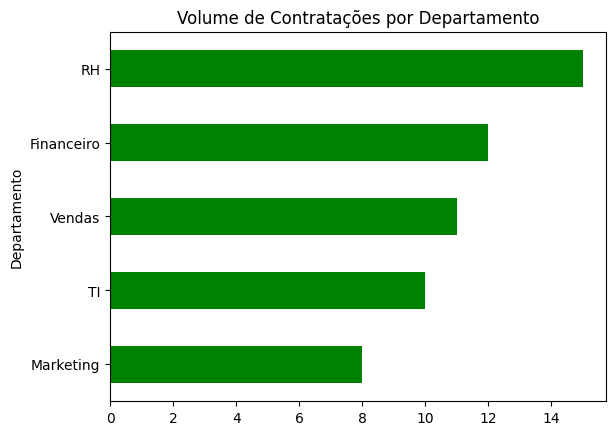

In [37]:
# Gráfico de Análise de Quantidade de Contratados por Departamento

analise_status['Contratado'].sort_values().plot(kind='barh', color='green', title='Volume de Contratações por Departamento')
plt.show()

### **Por fim, neste último trecho é analisado o tempo médio de fechamento geral (o SLA ou o TTO) e foi possível comparar em quais departamentos o número médio é maior**

In [32]:
#Média Geral de Dias para Fechamento

media_geral_tempo = df['Tempo_Dias'].mean()
print(f"Tempo Médio Geral de Contratação: {media_geral_tempo:.1f} dias")

Tempo Médio Geral de Contratação: 24.6 dias


In [34]:
# Média de Dias de Fechamento para cada Departamento

tempo_dept = df.groupby('Departamento')['Tempo_Dias'].mean().sort_values()

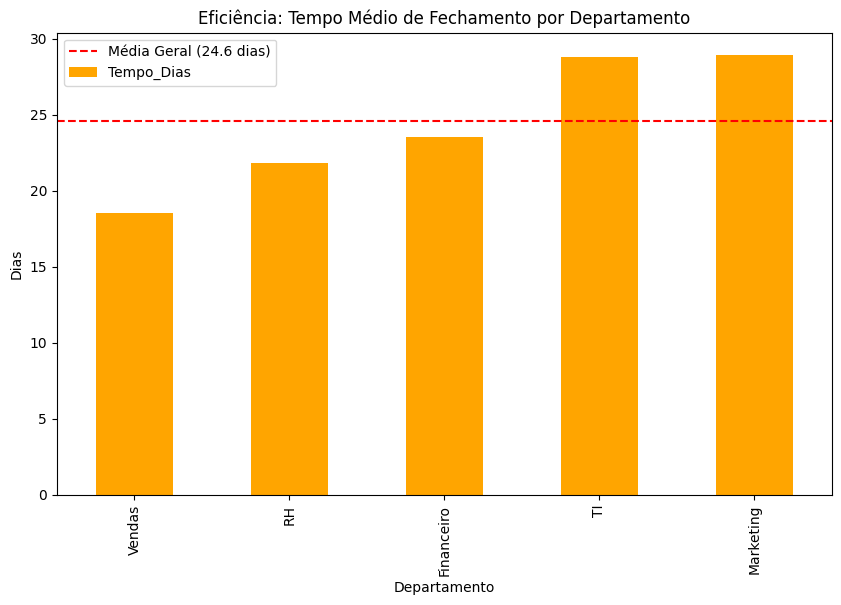

In [35]:
# Gráfico de Comparação de Média de Dias de Fechamento em cada Departamento

# Neste gráfico é possível perceber que os Departamentos de TI e Marketing, os quais possuem indicadores não favoráveis nos outros tópicos, também possue um tempo de fechamento médio maior do que os outros departamentos e também perante à média geral.

plt.figure(figsize=(10, 6))
tempo_dept.plot(kind='bar', color='orange')
plt.axhline(media_geral_tempo, color='red', linestyle='--', label=f'Média Geral ({media_geral_tempo:.1f} dias)')

plt.title('Eficiência: Tempo Médio de Fechamento por Departamento')
plt.ylabel('Dias')
plt.legend()
plt.show()